Car Damage Detection Model


    Dataset:
    `00-damage/`: Images of damaged cars
    `01-whole/`: Images of undamaged cars


1. Setup and Import Libraries

In [1]:

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import cv2
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from dataset import CarDamageDataset  






2. Dataset Setup


In [2]:





data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'car_damage_dataset'
train_dir = os.path.join(data_dir, 'training')
val_dir = os.path.join(data_dir, 'validation')

train_dataset = CarDamageDataset(train_dir, transform=data_transforms['train'])
val_dataset = CarDamageDataset(val_dir, transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Number of damaged cars in training: {sum(train_dataset.labels)}")
print(f"Number of undamaged cars in training: {len(train_dataset.labels) - sum(train_dataset.labels)}")



Training dataset size: 1840
Validation dataset size: 460
Number of damaged cars in training: 920
Number of undamaged cars in training: 920


# 
# ## 3. Model Definition




def create_model():
    model = models.resnet50(pretrained=True)

    for param in list(model.parameters())[:-20]:
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 1),
        nn.Sigmoid()
    )

    return model



# 
# ## 4. Training Function




In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cuda'):
    model = model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.float().to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    preds = (outputs > 0.5).float()
                    loss = criterion(outputs, labels.unsqueeze(1))

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.unsqueeze(1))

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

        print()

    print('Training complete')
    return model, history



In [4]:
def create_model():
    # Load pre-trained ResNet50 model
    model = models.resnet50(pretrained=True)
    
    # Freeze all layers except the last few
    for param in list(model.parameters())[:-20]:
        param.requires_grad = False
    
    # Modify the final layer for binary classification
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 1),
        nn.Sigmoid()
    )
    
    return model

# 
# ## 5. Train the Model




In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = create_model()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device=device)



Using device: cpu
Epoch 1/10
----------


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x1334122a0>
Traceback (most recent call last):
  File "/Users/sarvesh/sarvystuff/portfolio/DamageDoctor_III/DamageDoctor/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1479, in __del__
    self._shutdown_workers()
  File "/Users/sarvesh/sarvystuff/portfolio/DamageDoctor_III/DamageDoctor/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1443, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/Users/sarvesh/anaconda3/lib/python3.11/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sarvesh/anaconda3/lib/python3.11/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sarvesh/anaconda3/lib/python3.11/multiprocessing/connection.py", line 930, in wait
    ready = se

KeyboardInterrupt: 

# 
# ## 6. Visualize Training Results




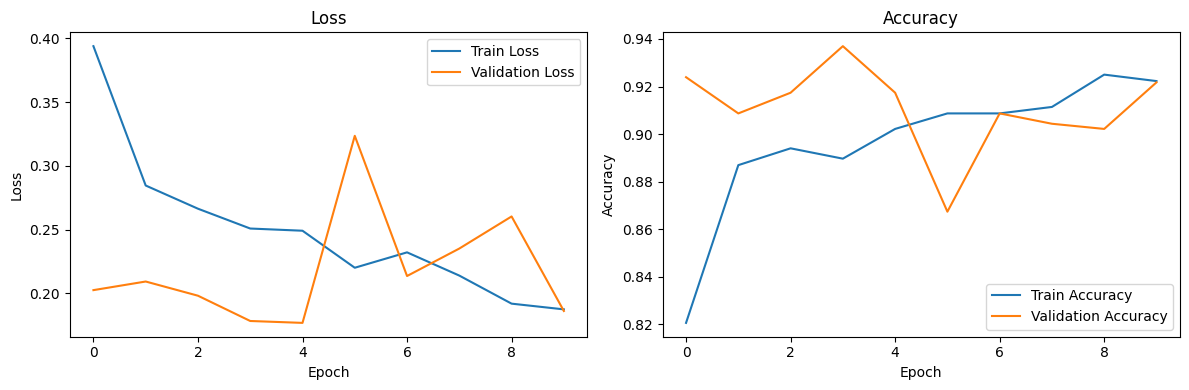

In [7]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)



# 
# ## 7. Evaluate Model Performance




Classification Report:
              precision    recall  f1-score   support

   No Damage       0.76      0.98      0.86       230
      Damage       0.98      0.69      0.81       230

    accuracy                           0.83       460
   macro avg       0.87      0.83      0.83       460
weighted avg       0.87      0.83      0.83       460



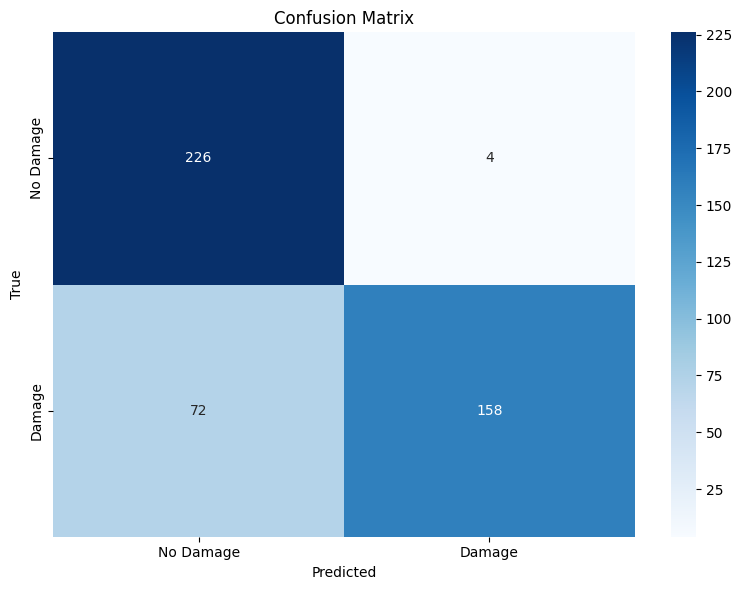

In [8]:
def evaluate_model(model, val_loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = (outputs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=['No Damage', 'Damage']))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Damage', 'Damage'],
                yticklabels=['No Damage', 'Damage'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

evaluate_model(model, val_loader, device)



# 
# ## 8. Save the Trained Model




In [9]:
torch.save(model.state_dict(), 'car_damage_binary_model.pth')
print("Model saved successfully.")



Model saved successfully.


# 
# ## 9. Inference with the Trained Model




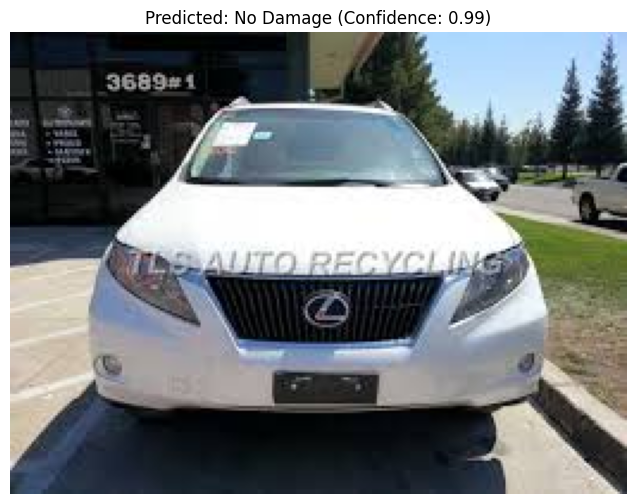

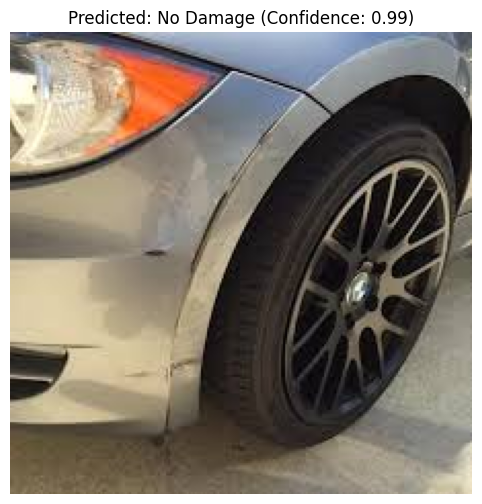

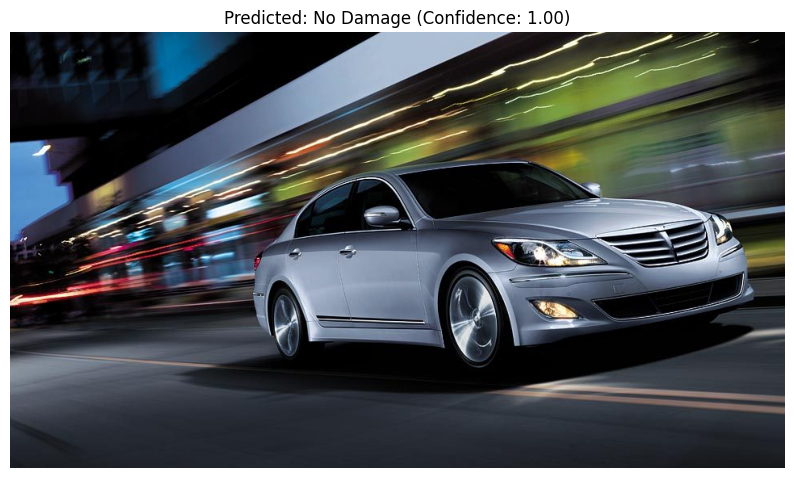

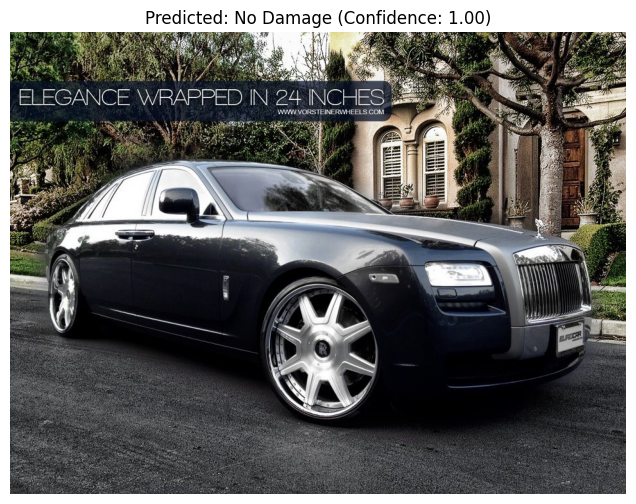

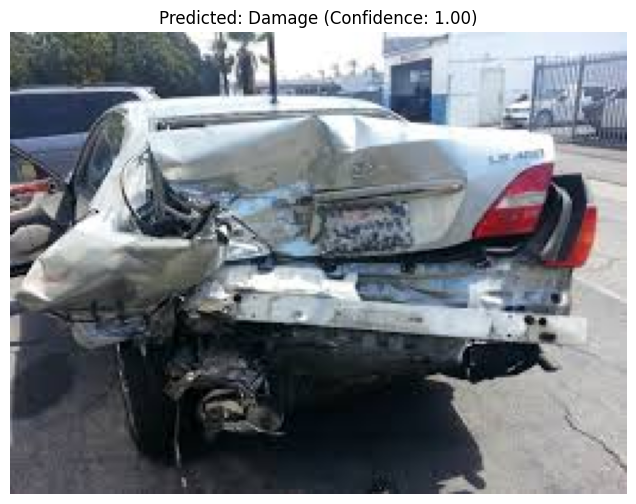

In [10]:
def predict_damage(model, image_path, transform, device):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probability = output.item()
        prediction = 'Damage' if probability > 0.5 else 'No Damage'

    return prediction, probability if prediction == 'Damage' else 1 - probability


def display_prediction(image_path, prediction, confidence):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(f"Predicted: {prediction} (Confidence: {confidence:.2f})")
    plt.axis('off')
    plt.show()


import random

val_image_files = []
for root, dirs, files in os.walk(val_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            val_image_files.append(os.path.join(root, file))

test_images = random.sample(val_image_files, min(5, len(val_image_files)))

for image_path in test_images:
    prediction, confidence = predict_damage(model, image_path, data_transforms['val'], device)
    display_prediction(image_path, prediction, confidence)
